# 1.
Write a Python function called simple_generator() that takes a random vector as input and returns a 28x28 array of grayscale pixel values between 0 and 1, simulating a fake handwritten digit image like those used in GAN demos.

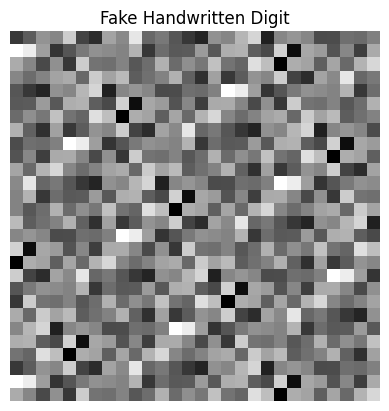

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simple_generator(random_vector):
    """
    Simulates a GAN generator by converting a random vector
    into a 28x28 grayscale image with values between 0 and 1.
    """
    
    # Ensure vector has 784 values (28x28)
    image = np.resize(random_vector, (28, 28))
    
    # Normalize values to range [0, 1]
    image = (image - image.min()) / (image.max() - image.min())
    
    return image

# Generate a random latent vector
latent_vector = np.random.randn(100)

# Generate fake image
fake_digit = simple_generator(latent_vector)

# Display image
plt.imshow(fake_digit, cmap='gray')
plt.title("Fake Handwritten Digit")
plt.axis('off')
plt.show()

# 2.
Create a Python class Discriminator with a method discriminate(image) that takes a 28x28 image array and returns a probability score between 0 and 1 indicating if the image is 'real' or 'fake'.<br><br><em><strong>Hint:</strong> For this exercise, use a simple rule (e.g., mean pixel value threshold) instead of a neural network.</em>

In [2]:
import numpy as np

class Discriminator:
    
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def discriminate(self, image):
        """
        Takes a 28x28 image array and returns
        a probability score between 0 and 1.
        """
        
        # Calculate mean pixel value
        mean_pixel = np.mean(image)

        # Simple rule-based probability
        if mean_pixel >= self.threshold:
            probability = 0.9   # likely real
        else:
            probability = 0.1   # likely fake

        return probability


# Example usage
discriminator = Discriminator(threshold=0.5)

# Create a sample 28x28 image
image = np.random.rand(28, 28)

score = discriminator.discriminate(image)

print("Probability image is real:", score)

Probability image is real: 0.9


# 3.
Simulate one cycle of the adversarial training loop: generate a fake image using your simple_generator(), get a score from your Discriminator, and print whether the Discriminator correctly identifies the fake image.

In [4]:
import numpy as np

# ---------- Generator ----------
def simple_generator(random_vector):
    image = np.resize(random_vector, (28, 28))
    image = (image - image.min()) / (image.max() - image.min())
    return image


# ---------- Discriminator ----------
class Discriminator:

    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def discriminate(self, image):

        mean_pixel = np.mean(image)

        if mean_pixel >= self.threshold:
            return 0.9  # likely real
        else:
            return 0.1  # likely fake


# ---------- Adversarial Training Cycle ----------

# Step 1: Generate fake image
latent_vector = np.random.randn(100)
fake_image = simple_generator(latent_vector)

# Step 2: Create discriminator
discriminator = Discriminator()

# Step 3: Get discriminator score
score = discriminator.discriminate(fake_image)

# Step 4: Check prediction
if score < 0.5:
    print("Discriminator correctly identified the image as FAKE.")
else:
    print("Discriminator incorrectly classified the fake image as REAL.")

print("Discriminator Score:", score)

Discriminator correctly identified the image as FAKE.
Discriminator Score: 0.1


# 4.
Research and list two real-world apps or features (outside of face generation) that use GANs for image-to-image translation, artistic style transfer, or deepfakes. For each, write one line on how GANs enable the feature.

# Real-World Applications of GANs

| Application / Feature | How GANs Enable the Feature |
|----------------------|-----------------------------|
| **Snapchat Filters** | GANs can transform facial features in real time, enabling effects such as age changes, gender swaps, and artistic face transformations. |
| **NVIDIA GauGAN** | GANs convert simple sketches and segmentation maps into realistic landscape images by learning how real-world scenes look. |

## Alternative Examples

| Application / Feature | How GANs Enable the Feature |
|----------------------|-----------------------------|
| **Prisma Style Transfer** | GAN-based techniques can transform ordinary photos into images that mimic famous artistic styles and paintings. |
| **Deepfake Video Apps** | GANs learn facial expressions and appearance patterns to realistically replace or animate faces in videos. |

# 5.
Use ChatGPT or Copilot to generate a short explanation (3-4 lines) of the difference between DCGAN, StyleGAN, and CycleGAN. Paste the AI's response and state one thing you learned that you didn't know before.

# AI-Generated Response

DCGAN (Deep Convolutional GAN) uses convolutional neural networks to generate images from random noise and is commonly used for basic image generation tasks. StyleGAN improves upon GANs by giving fine-grained control over image features such as hairstyle, facial attributes, and texture, producing highly realistic images. CycleGAN is designed for image-to-image translation and can convert images from one domain to another (for example, horses to zebras) without requiring paired training examples. While DCGAN focuses on generating images, StyleGAN focuses on controllable high-quality image synthesis, and CycleGAN focuses on transforming existing images.

# One Thing I Learned

Before this exercise, I did not know that **CycleGAN can learn image-to-image translation without needing paired examples**. For instance, it can learn to convert horse images into zebra images even when the training dataset does not contain matching horse-zebra image pairs.